# 04 — SkillCorner Tracking & Physical-Load Exploration

**Scope:** Prototype physical-load feature engineering from SkillCorner's open
broadcast-tracking data (10 A-League 2024/25 matches, 10 fps).

**Goal:** Parse tracking → smooth speed/acceleration → compute distance,
high-speed running, sprint, acceleration counts, possession-phase splits,
and phase-of-play exposure.  Build a reusable `player_match_physical` table.

> **Note:** This is a *feature-prototyping* notebook—the population
> (Australian A-League) differs from the intended UEFA men's injury model.
> Methods developed here will transfer; the data itself is auxiliary.

*Data credit: [SkillCorner](https://skillcorner.com) ×
[PySport](https://pysport.org)*

In [1]:
import json, pathlib, warnings, textwrap
from io import StringIO

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns
from scipy.signal import savgol_filter

warnings.filterwarnings("ignore", category=FutureWarning)
pd.set_option("display.max_columns", 60)
sns.set_theme(style="whitegrid", palette="muted", font_scale=0.9)

%matplotlib inline

## 1 &ensp; Configuration & Helpers

In [2]:
# -- paths --
ROOT      = pathlib.Path.cwd().parent            # repo root
DATA_SC   = ROOT / "data" / "opendata" / "data"  # SkillCorner data root
MATCH_DIR = DATA_SC / "matches"
AGG_CSV   = DATA_SC / "aggregates" / "aus1league_physicalaggregates_20242025.csv"

# -- physical thresholds (m/s and m/s^2) --
SPEED_WALK     = 1.5   # m/s  walking
SPEED_JOG      = 4.0   # m/s  jogging upper bound
SPEED_RUN      = 5.5   # m/s  running / HSR lower bound
SPEED_SPRINT   = 7.0   # m/s  sprint lower bound
ACCEL_MED      = 2.0   # m/s^2  medium acceleration lower bound
ACCEL_HIGH     = 4.0   # m/s^2  high acceleration lower bound
DECEL_MED      = -4.0  # m/s^2  high deceleration
DECEL_MOD      = -2.0  # m/s^2  medium deceleration

FPS = 10   # frames per second
DT  = 1 / FPS

# -- helper: check LFS pointer --
def is_lfs_pointer(path: pathlib.Path) -> bool:
    """Return True if file is a Git-LFS pointer (< 300 bytes, starts with version)."""
    if path.stat().st_size > 300:
        return False
    with open(path, "r", encoding="utf-8") as f:
        first_line = f.readline()
    return first_line.startswith("version https://git-lfs")


def resolve_tracking_path(match_id: int) -> pathlib.Path:
    """Return the local JSONL path, downloading from GitHub LFS if needed."""
    local = MATCH_DIR / str(match_id) / f"{match_id}_tracking_extrapolated.jsonl"
    if local.exists() and not is_lfs_pointer(local):
        return local
    # Download from SkillCorner GitHub (LFS media URL)
    import urllib.request
    url = (
        f"https://media.githubusercontent.com/media/SkillCorner/opendata/"
        f"master/data/matches/{match_id}/{match_id}_tracking_extrapolated.jsonl"
    )
    print(f"  downloading tracking for match {match_id} (~85 MB) ...")
    urllib.request.urlretrieve(url, local)
    print(f"    saved: {local.name}  ({local.stat().st_size / 1e6:.1f} MB)")
    return local


def time_to_seconds(t: str) -> float:
    """Convert HH:MM:SS or MM:SS.s to total seconds."""
    parts = t.split(":")
    if len(parts) == 3:
        return int(parts[0]) * 3600 + int(parts[1]) * 60 + float(parts[2])
    elif len(parts) == 2:
        return int(parts[0]) * 60 + float(parts[1])
    return float(t)


def count_bouts(series: pd.Series, threshold: float) -> int:
    """Count distinct bouts where value exceeds threshold."""
    above = (series >= threshold).astype(int)
    starts = above.diff().fillna(above).clip(lower=0)
    return int(starts.sum())


print("paths OK:", MATCH_DIR)
print("match folders:", sorted([p.name for p in MATCH_DIR.iterdir() if p.is_dir()]))

paths OK: c:\Users\storm\Documents\Courses_IMT_Atlantique\A Journey to a Data Scientist\Business Problem\data_exploration\data\opendata\data\matches
match folders: ['1886347', '1899585', '1925299', '1953632', '1996435', '2006229', '2011166', '2013725', '2015213', '2017461']


## 2 &ensp; Data Inventory — 10 A-League Matches

In [3]:
matches_meta = pd.read_json(DATA_SC / "matches.json")
matches_meta["date_time"] = pd.to_datetime(matches_meta["date_time"])
matches_meta["home"] = matches_meta["home_team"].apply(lambda d: d["short_name"])
matches_meta["away"] = matches_meta["away_team"].apply(lambda d: d["short_name"])
matches_meta = matches_meta.sort_values("date_time").reset_index(drop=True)
matches_meta[["id", "date_time", "home", "away"]]

,id,date_time,home,away
0,1886347,2024-11-30 04:00:00+00:00,Auckland FC,Newcastle
1,1899585,2024-12-07 04:00:00+00:00,Auckland FC,Wellington P FC
2,1925299,2024-12-21 06:00:00+00:00,Brisbane FC,Perth Glory
3,1953632,2024-12-31 08:00:00+00:00,CC Mariners,Melbourne City
4,1996435,2025-02-01 06:00:00+00:00,Sydney FC,Adelaide United
5,2006229,2025-03-07 08:35:00+00:00,Melbourne City,Macarthur FC
6,2011166,2025-04-12 05:00:00+00:00,Wellington P FC,Melbourne V FC
7,2013725,2025-04-27 07:00:00+00:00,Western United,Sydney FC
8,2015213,2025-05-03 08:00:00+00:00,Western United,Auckland FC
9,2017461,2025-05-17 09:35:00+00:00,Melbourne V FC,Auckland FC


## 3 &ensp; Match Metadata & Lineup (single-match deep dive)

In [4]:
MATCH_ID = matches_meta["id"].iloc[0]  # first chronological match
print(f"Deep-dive match: {MATCH_ID}")

with open(MATCH_DIR / str(MATCH_ID) / f"{MATCH_ID}_match.json") as f:
    match_data = json.load(f)

pitch_length = match_data["pitch_length"]
pitch_width  = match_data["pitch_width"]
print(f"Pitch: {pitch_length} x {pitch_width} m")
print(f"Periods: {match_data['match_periods']}")

# -- players table --
players_raw = pd.json_normalize(match_data["players"], max_level=2)
players = players_raw[players_raw["start_time"].notna()].copy()
players["minutes_played"] = (
    players["playing_time.total.minutes_played"]
)
players["team_id"] = players["team_id"].astype(int)

# add team short name
home_id = match_data["home_team"]["id"]
away_id = match_data["away_team"]["id"]
home_name = match_data["home_team"]["short_name"]
away_name = match_data["away_team"]["short_name"]
players["team"] = players["team_id"].map({home_id: home_name, away_id: away_name})

cols = ["id", "short_name", "number", "player_role.acronym",
        "team", "minutes_played", "trackable_object"]
players[cols].sort_values(["team", "number"])

Deep-dive match: 1886347
Pitch: 104 x 68 m
Periods: [{'period': 1, 'name': 'period_1', 'start_frame': 10, 'end_frame': 27790, 'duration_frames': 27780, 'duration_minutes': 46.3}, {'period': 2, 'name': 'period_2', 'start_frame': 27800, 'end_frame': 59060, 'duration_frames': 31260, 'duration_minutes': 52.1}]


,id,short_name,number,player_role.acronym,team,minutes_played,trackable_object
5,33697,N. Pijnaker,4,LCB,Auckland FC,98.40,34805
24,31147,T. Smith,5,CB,Auckland FC,11.75,32245
7,14736,L. Verstraete,6,DM,Auckland FC,98.40,14933
25,163972,M. Mata,9,CF,Auckland FC,20.48,165527
0,38673,G. May,10,CF,Auckland FC,86.65,39794
35,285188,A. Paulsen,12,GK,Auckland FC,98.40,286745
18,965685,L. Gillion,14,LW,Auckland FC,98.40,967248
4,133498,F. De Vries,15,LB,Auckland FC,98.40,135053
1,51713,C. Elliott,17,RB,Auckland FC,98.40,52839
2,50951,J. Brimmer,22,CF,Auckland FC,77.91,52077


## 4 &ensp; Parse Tracking Data

Each JSONL line is one frame (10 fps).  We flatten `player_data` to get a
row per player-frame with `(x, y, player_id, is_detected)` plus frame-level
fields (`frame`, `timestamp`, `period`, `possession`, `ball_data`).

In [5]:
tracking_path = resolve_tracking_path(MATCH_ID)

# read JSONL -- each line is a JSON object (one frame)
raw = pd.read_json(tracking_path, lines=True)
print(f"Frames loaded: {len(raw):,}")

# flatten player_data (one row per player-frame)
tk = pd.json_normalize(
    raw.to_dict("records"),
    record_path="player_data",
    meta=["frame", "timestamp", "period", "possession", "ball_data"],
)

# extract possession info
tk["possession_group"]     = tk["possession"].apply(
    lambda d: d.get("group") if isinstance(d, dict) else None
)
tk["possession_player_id"] = tk["possession"].apply(
    lambda d: d.get("player_id") if isinstance(d, dict) else None
)

# extract ball position
ball = pd.json_normalize(tk["ball_data"].dropna())
if len(ball) > 0 and "x" in ball.columns:
    tk.loc[ball.index, "ball_x"] = ball["x"].values
    tk.loc[ball.index, "ball_y"] = ball["y"].values

tk.drop(columns=["possession", "ball_data"], inplace=True)

# types
tk["frame"]       = tk["frame"].astype(int)
tk["player_id"]   = tk["player_id"].astype(int)
tk["is_detected"] = tk["is_detected"].astype(bool)
tk["period"]      = tk["period"].astype(int)

tk = tk.sort_values(["player_id", "frame"]).reset_index(drop=True)

print(f"Player-frames: {tk.shape[0]:,}  |  Unique players: {tk['player_id'].nunique()}"
      f"  |  Frame range: {tk['frame'].min()} - {tk['frame'].max()}")
tk.head()

Frames loaded: 59,061
Player-frames: 956,076  |  Unique players: 29  |  Frame range: 10 - 59038


,x,y,player_id,is_detected,frame,timestamp,period,possession_group,possession_player_id,ball_x,ball_y
0,11.70,6.73,14736,True,10,2026-03-21 00:00:00.000,1,NaN,NaN,0.32,0.38
1,11.58,6.69,14736,True,11,2026-03-21 00:00:00.100,1,NaN,NaN,0.54,0.08
2,11.46,6.66,14736,True,12,2026-03-21 00:00:00.200,1,NaN,NaN,0.57,-0.07
3,11.34,6.63,14736,True,13,2026-03-21 00:00:00.300,1,NaN,NaN,0.56,-0.07
4,11.22,6.61,14736,True,14,2026-03-21 00:00:00.400,1,NaN,NaN,0.59,-0.03


### 4.1 &ensp; Coverage check — detected vs extrapolated

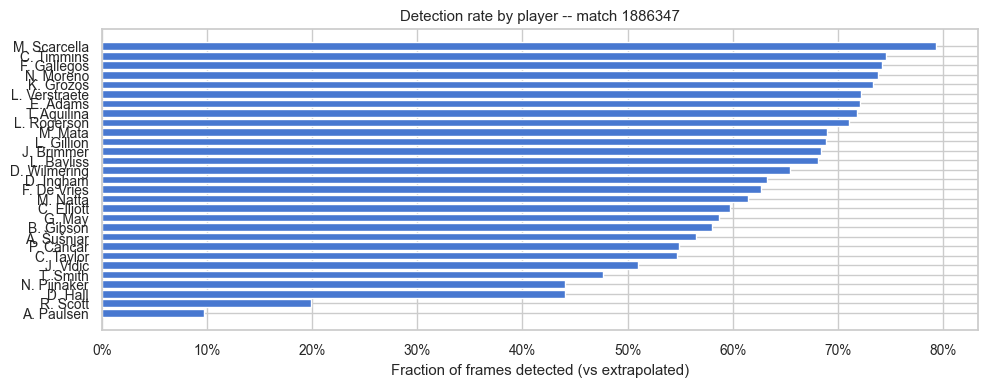

In [6]:
det = tk.groupby("player_id")["is_detected"].mean().reset_index()
det.columns = ["player_id", "pct_detected"]
det = det.merge(players[["id", "short_name", "team", "player_role.acronym"]],
                left_on="player_id", right_on="id", how="left")

fig, ax = plt.subplots(figsize=(10, 4))
det_sorted = det.sort_values("pct_detected")
ax.barh(det_sorted["short_name"], det_sorted["pct_detected"])
ax.set_xlabel("Fraction of frames detected (vs extrapolated)")
ax.set_title(f"Detection rate by player -- match {MATCH_ID}")
ax.xaxis.set_major_formatter(mtick.PercentFormatter(1.0))
plt.tight_layout()
plt.show()

## 5 &ensp; Speed & Acceleration

**Method:**
1. Raw speed = Euclidean displacement / dt  (10 fps, dt = 0.1 s)
2. Savitzky-Golay smoothing (window 7, poly 2) to remove tracking noise
3. Acceleration = d(speed) / dt on the smoothed signal

In [7]:
def compute_kinematics(group: pd.DataFrame) -> pd.DataFrame:
    """Compute speed (m/s) and acceleration (m/s^2) for one player."""
    g = group.sort_values("frame").copy()

    # displacement
    dx = g["x"].diff()
    dy = g["y"].diff()
    dist = np.sqrt(dx**2 + dy**2)

    # detect frame gaps (> 1 frame apart = break)
    dframe = g["frame"].diff()
    continuous = dframe == 1

    # raw speed (m/s)
    raw_speed = dist / DT
    raw_speed[~continuous] = np.nan

    # cap implausible speeds (> 12 m/s ~ 43 km/h)
    raw_speed = raw_speed.clip(upper=12.0)

    # smooth speed with Savitzky-Golay (window must be odd, <= len)
    n = len(raw_speed.dropna())
    if n >= 7:
        filled = raw_speed.interpolate(limit=3).fillna(0)
        win = min(7, n if n % 2 == 1 else n - 1)
        smooth = savgol_filter(filled, window_length=win, polyorder=2)
        smooth = np.clip(smooth, 0, 12.0)
    else:
        smooth = raw_speed.fillna(0).values

    g["speed_raw"]      = raw_speed.values
    g["speed"]          = smooth
    g["dist_frame"]     = dist.values
    g["dist_frame"]     = g["dist_frame"].fillna(0).clip(upper=1.2)
    g["acceleration"]   = np.gradient(smooth, DT)

    # smooth acceleration lightly
    if len(g) >= 5:
        g["acceleration"] = savgol_filter(g["acceleration"],
                                          window_length=5, polyorder=2)

    return g

# apply per-player kinematics (manual loop avoids groupby.apply pandas version issues)
tk = pd.concat([compute_kinematics(g) for _, g in tk.groupby("player_id")])
tk = tk.reset_index(drop=True)
print("Kinematics computed")
tk[["player_id", "frame", "x", "y", "speed_raw", "speed",
    "acceleration", "dist_frame"]].head(10)

Kinematics computed


,player_id,frame,x,y,speed_raw,speed,acceleration,dist_frame
0,14736,10,11.70,6.73,NaN,0.300143,5.294212,0.000000
1,14736,11,11.58,6.69,1.264911,0.811166,4.004926,0.126491
2,14736,12,11.46,6.66,1.236932,1.160629,2.475448,0.123693
3,14736,13,11.34,6.63,1.236932,1.348533,0.273748,0.123693
4,14736,14,11.22,6.61,1.216553,1.185913,-0.772153,0.121655
5,14736,15,11.11,6.59,1.118034,1.138605,-0.487836,0.111803
6,14736,16,11.00,6.58,1.104536,1.139714,-0.025808,0.110454
7,14736,17,10.89,6.56,1.118034,1.129676,-0.129087,0.111803
8,14736,18,10.77,6.58,1.216553,1.115496,-0.293359,0.121655
9,14736,19,10.67,6.60,1.019804,1.067561,-0.364142,0.101980


### 5.1 &ensp; Speed trace — single player, first half

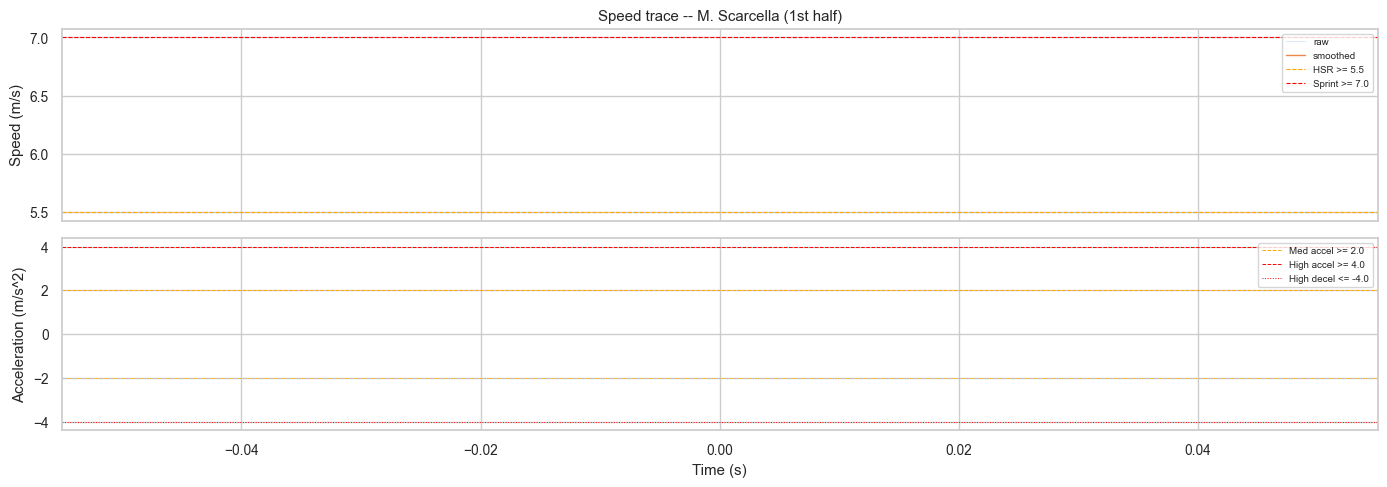

In [8]:
# pick a starter with high detection rate
sample_player_id = det.sort_values("pct_detected", ascending=False).iloc[0]["player_id"]
sample_name = det.loc[det["player_id"] == sample_player_id, "short_name"].iloc[0]

mask = (tk["player_id"] == sample_player_id) & (tk["period"] == 1)
seg = tk.loc[mask].copy()
seg["time_s"] = (seg["frame"] - seg["frame"].min()) / FPS

fig, axes = plt.subplots(2, 1, figsize=(14, 5), sharex=True)

# speed
axes[0].plot(seg["time_s"], seg["speed_raw"], alpha=0.25, lw=0.5, label="raw")
axes[0].plot(seg["time_s"], seg["speed"], lw=1, label="smoothed")
axes[0].axhline(SPEED_RUN, color="orange", ls="--", lw=0.8, label=f"HSR >= {SPEED_RUN}")
axes[0].axhline(SPEED_SPRINT, color="red", ls="--", lw=0.8, label=f"Sprint >= {SPEED_SPRINT}")
axes[0].set_ylabel("Speed (m/s)")
axes[0].set_title(f"Speed trace -- {sample_name} (1st half)")
axes[0].legend(loc="upper right", fontsize=7)

# acceleration
axes[1].plot(seg["time_s"], seg["acceleration"], lw=0.8, color="seagreen")
axes[1].axhline(ACCEL_MED, color="orange", ls="--", lw=0.7, label=f"Med accel >= {ACCEL_MED}")
axes[1].axhline(ACCEL_HIGH, color="red", ls="--", lw=0.7, label=f"High accel >= {ACCEL_HIGH}")
axes[1].axhline(DECEL_MOD, color="orange", ls=":", lw=0.7)
axes[1].axhline(DECEL_MED, color="red", ls=":", lw=0.7, label=f"High decel <= {DECEL_MED}")
axes[1].set_ylabel("Acceleration (m/s^2)")
axes[1].set_xlabel("Time (s)")
axes[1].legend(loc="upper right", fontsize=7)

plt.tight_layout()
plt.show()

## 6 &ensp; Distance

Total distance per player, computed as the sum of frame-to-frame
Euclidean displacements (capped at 1.2 m/frame to exclude
teleportation artefacts).

In [9]:
player_dist = (
    tk.groupby("player_id")
    .agg(
        total_distance=("dist_frame", "sum"),
        n_frames=("frame", "count"),
    )
    .reset_index()
)
player_dist["minutes"] = player_dist["n_frames"] / FPS / 60
player_dist["m_per_min"] = player_dist["total_distance"] / player_dist["minutes"]

player_dist = player_dist.merge(
    players[["id", "short_name", "team", "player_role.acronym", "minutes_played"]],
    left_on="player_id", right_on="id", how="left",
)

print(player_dist[["short_name", "team", "player_role.acronym",
                    "total_distance", "minutes", "m_per_min"]]
      .sort_values("total_distance", ascending=False)
      .to_string(index=False, float_format="%.1f"))

   short_name        team player_role.acronym  total_distance  minutes  m_per_min
  F. Gallegos Auckland FC                  AM         11384.2     72.4      157.2
L. Verstraete Auckland FC                  DM         10844.4     72.4      149.7
   L. Gillion Auckland FC                  LW         10351.5     72.4      142.9
  T. Aquilina   Newcastle                  LW         10334.6     72.4      142.7
   C. Timmins   Newcastle                 LDM         10061.8     65.5      153.7
    K. Grozos   Newcastle                 RDM         10058.8     72.4      138.9
  F. De Vries Auckland FC                  LB          9487.3     72.4      131.0
   C. Elliott Auckland FC                  RB          9296.1     72.4      128.3
    D. Ingham   Newcastle                  RB          9138.3     72.4      126.2
     M. Natta   Newcastle                  LB          9013.8     72.4      124.4
     E. Adams   Newcastle                  RW          8951.5     65.5      136.7
   A. Šušnjar   

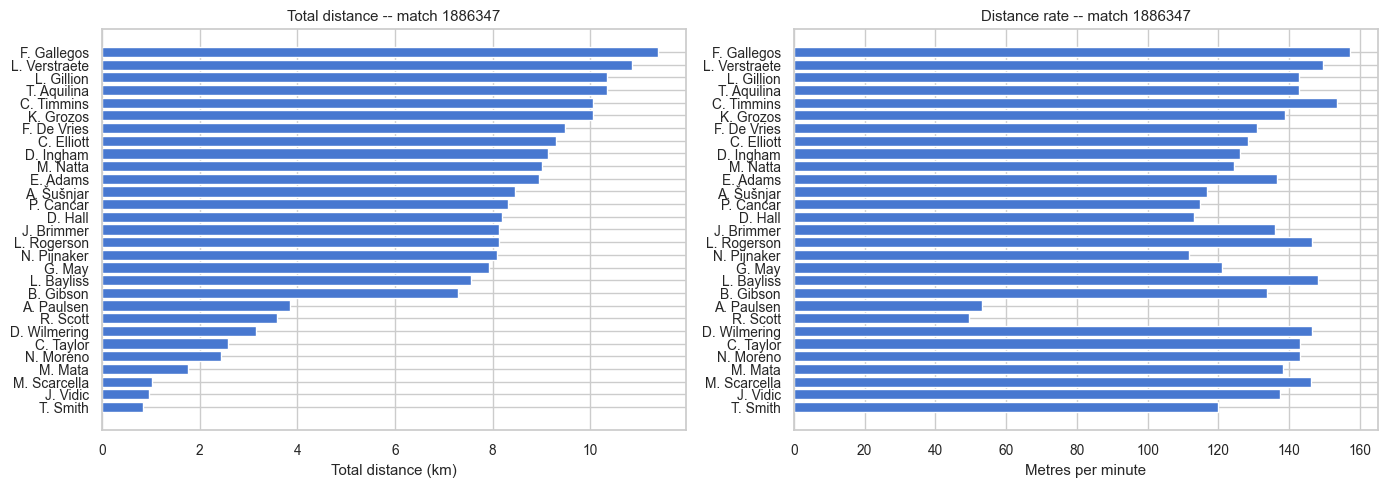

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# total distance
d = player_dist.sort_values("total_distance", ascending=True)
axes[0].barh(d["short_name"], d["total_distance"] / 1000)
axes[0].set_xlabel("Total distance (km)")
axes[0].set_title(f"Total distance -- match {MATCH_ID}")

# metres per minute
axes[1].barh(d["short_name"], d["m_per_min"])
axes[1].set_xlabel("Metres per minute")
axes[1].set_title(f"Distance rate -- match {MATCH_ID}")

plt.tight_layout()
plt.show()

## 7 &ensp; High-Speed Running & Sprint Proxies

| Band | Speed range |
|------|------------|
| Walking | < 1.5 m/s |
| Jogging | 1.5 - 4.0 m/s |
| Running | 4.0 - 5.5 m/s |
| **HSR** | **5.5 - 7.0 m/s** |
| **Sprint** | **>= 7.0 m/s** |

In [11]:
def speed_band(s):
    if s < SPEED_WALK:   return "walking"
    if s < SPEED_JOG:    return "jogging"
    if s < SPEED_RUN:    return "running"
    if s < SPEED_SPRINT: return "HSR"
    return "sprint"

tk["speed_band"] = tk["speed"].apply(speed_band)

# per-player speed-band distance
band_dist = (
    tk.groupby(["player_id", "speed_band"])["dist_frame"]
    .sum()
    .unstack(fill_value=0)
    .reset_index()
)

band_dist = band_dist.merge(
    players[["id", "short_name", "team", "player_role.acronym"]],
    left_on="player_id", right_on="id", how="left",
)

# Ensure HSR/sprint columns exist
for c in ["HSR", "sprint"]:
    if c not in band_dist.columns:
        band_dist[c] = 0.0

band_dist["hsr_distance"]    = band_dist["HSR"]
band_dist["sprint_distance"] = band_dist["sprint"]
band_dist["hi_distance"]     = band_dist["hsr_distance"] + band_dist["sprint_distance"]

print(band_dist[["short_name", "team", "player_role.acronym",
                  "hsr_distance", "sprint_distance", "hi_distance"]]
      .sort_values("hi_distance", ascending=False)
      .to_string(index=False, float_format="%.0f"))

   short_name        team player_role.acronym  hsr_distance  sprint_distance  hi_distance
  F. Gallegos Auckland FC                  AM          1322              176         1498
  T. Aquilina   Newcastle                  LW          1045              208         1253
   L. Gillion Auckland FC                  LW           854              318         1172
  L. Rogerson Auckland FC                  RW           867              125          992
     E. Adams   Newcastle                  RW           835              126          961
   J. Brimmer Auckland FC                  CF           749              195          944
  F. De Vries Auckland FC                  LB           797              122          919
       G. May Auckland FC                  CF           770              146          916
   C. Elliott Auckland FC                  RB           715              158          872
L. Verstraete Auckland FC                  DM           792               49          841
    D. Ing

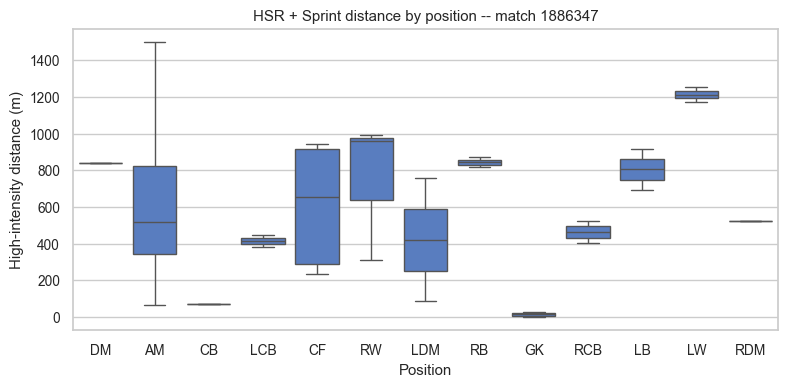

In [12]:
# HSR + sprint bout counts
hsr_sprint_counts = (
    tk.groupby("player_id")["speed"]
    .agg(
        hsr_count=lambda s: count_bouts(s, SPEED_RUN),
        sprint_count=lambda s: count_bouts(s, SPEED_SPRINT),
    )
    .reset_index()
)

band_dist = band_dist.merge(hsr_sprint_counts, on="player_id", how="left")

# visualise by position group
fig, ax = plt.subplots(figsize=(8, 4))
plot_df = band_dist.dropna(subset=["player_role.acronym"])
sns.boxplot(data=plot_df, x="player_role.acronym", y="hi_distance", ax=ax)
ax.set_xlabel("Position")
ax.set_ylabel("High-intensity distance (m)")
ax.set_title(f"HSR + Sprint distance by position -- match {MATCH_ID}")
plt.tight_layout()
plt.show()

## 8 &ensp; Acceleration & Deceleration Counts

| Category | Threshold |
|----------|----------|
| Medium acceleration | 2.0 - 4.0 m/s^2 |
| High acceleration | >= 4.0 m/s^2 |
| Medium deceleration | -4.0 to -2.0 m/s^2 |
| High deceleration | <= -4.0 m/s^2 |

In [13]:
def count_accel_events(group: pd.DataFrame) -> pd.Series:
    a = group["acceleration"]
    return pd.Series({
        "med_accel_count":  count_bouts(a, ACCEL_MED) - count_bouts(a, ACCEL_HIGH),
        "high_accel_count": count_bouts(a, ACCEL_HIGH),
        "med_decel_count":  count_bouts(-a, ACCEL_MED) - count_bouts(-a, ACCEL_HIGH),
        "high_decel_count": count_bouts(-a, ACCEL_HIGH),
    })

accel_counts = tk.groupby("player_id").apply(count_accel_events).reset_index()
accel_counts = accel_counts.merge(
    players[["id", "short_name", "team", "player_role.acronym"]],
    left_on="player_id", right_on="id", how="left",
)

print(accel_counts[["short_name", "team", "player_role.acronym",
                     "med_accel_count", "high_accel_count",
                     "med_decel_count", "high_decel_count"]]
      .sort_values("high_accel_count", ascending=False)
      .to_string(index=False))

   short_name        team player_role.acronym  med_accel_count  high_accel_count  med_decel_count  high_decel_count
   L. Gillion Auckland FC                  LW              265                58              270                59
    D. Ingham   Newcastle                  RB              210                49              208                63
  L. Rogerson Auckland FC                  RW              194                39              201                44
   C. Elliott Auckland FC                  RB              242                37              215                60
     M. Natta   Newcastle                  LB              234                35              225                50
    P. Cancar   Newcastle                 RCB              212                34              202                35
  F. Gallegos Auckland FC                  AM              233                34              274                40
  T. Aquilina   Newcastle                  LW              235          

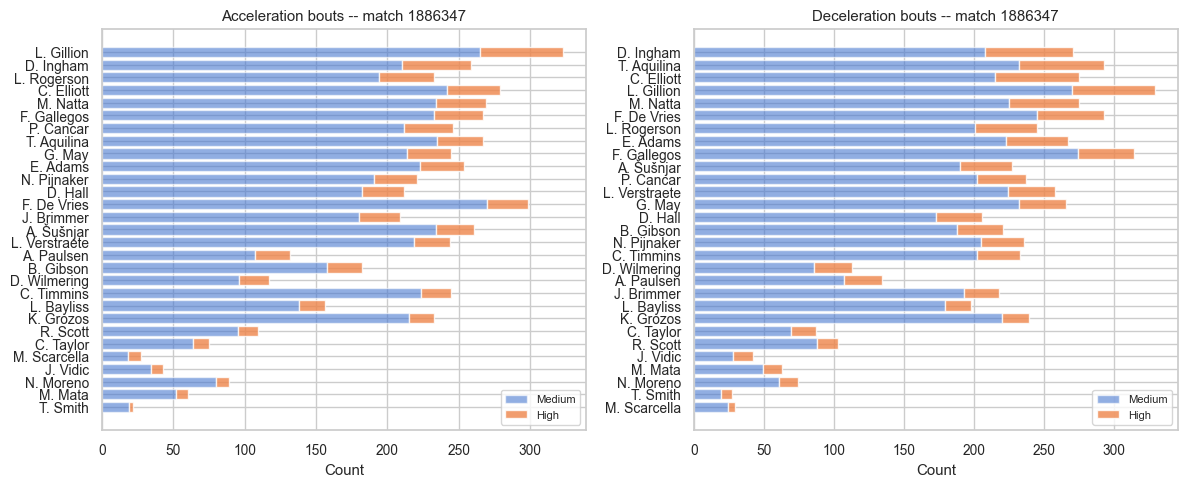

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
for i, col_pair in enumerate([("med_accel_count", "high_accel_count"),
                               ("med_decel_count", "high_decel_count")]):
    d = accel_counts.sort_values(col_pair[1], ascending=True)
    axes[i].barh(d["short_name"], d[col_pair[0]], label="Medium", alpha=0.6)
    axes[i].barh(d["short_name"], d[col_pair[1]], left=d[col_pair[0]],
                 label="High", alpha=0.8)
    axes[i].set_xlabel("Count")
    tag = "Acceleration" if i == 0 else "Deceleration"
    axes[i].set_title(f"{tag} bouts -- match {MATCH_ID}")
    axes[i].legend(fontsize=8)
plt.tight_layout()
plt.show()

## 9 &ensp; Possession-Phase Splits

Join the tracking data with SkillCorner's **phases-of-play** file to split
physical output by in-possession (`tip`) vs out-of-possession (`otip`).

In [15]:
phases = pd.read_csv(
    MATCH_DIR / str(MATCH_ID) / f"{MATCH_ID}_phases_of_play.csv"
)
print(f"Phases: {len(phases)}  |  Columns: {list(phases.columns[:12])}")
phases[["index", "frame_start", "frame_end", "team_in_possession_shortname",
        "team_in_possession_phase_type", "team_out_of_possession_phase_type",
        "duration"]].head(8)

Phases: 454  |  Columns: ['index', 'match_id', 'frame_start', 'frame_end', 'time_start', 'time_end', 'minute_start', 'second_start', 'duration', 'period', 'attacking_side_id', 'team_in_possession_id']


,index,frame_start,frame_end,team_in_possession_shortname,team_in_possession_phase_type,team_out_of_possession_phase_type,duration
0,0,28,89,Newcastle,create,medium_block,6.1
1,1,89,107,Newcastle,direct,defending_direct,1.8
2,2,185,232,Auckland FC,build_up,high_block,4.7
3,3,232,283,Auckland FC,create,medium_block,5.1
4,4,283,301,Newcastle,chaotic,chaotic,1.8
5,5,301,351,Auckland FC,finish,low_block,5.0
6,6,351,504,Newcastle,build_up,high_block,15.3
7,7,504,526,Newcastle,direct,defending_direct,2.2


In [16]:
def assign_phase(tk_df, phases_df):
    """Add possession state columns to tracking data."""
    tk_df = tk_df.copy()
    tk_df["in_possession"] = np.nan
    tk_df["phase_type_ip"]  = None
    tk_df["phase_type_oop"] = None

    # get team for each player
    player_team = players.set_index("id")["team"].to_dict()
    tk_df["player_team"] = tk_df["player_id"].map(player_team)

    for _, phase in phases_df.iterrows():
        fmask = ((tk_df["frame"] >= phase["frame_start"]) &
                 (tk_df["frame"] <= phase["frame_end"]))
        tip_team = phase["team_in_possession_shortname"]

        ip_mask  = fmask & (tk_df["player_team"] == tip_team)
        oop_mask = fmask & (tk_df["player_team"] != tip_team) & tk_df["player_team"].notna()

        tk_df.loc[ip_mask, "in_possession"]  = 1
        tk_df.loc[oop_mask, "in_possession"] = 0
        tk_df.loc[ip_mask, "phase_type_ip"]  = phase["team_in_possession_phase_type"]
        tk_df.loc[oop_mask, "phase_type_oop"] = phase["team_out_of_possession_phase_type"]

    return tk_df

tk = assign_phase(tk, phases)
pct_assigned = tk["in_possession"].notna().mean()
print(f"Frames with possession label: {pct_assigned:.1%}")

Frames with possession label: 72.2%


In [17]:
# Distance split by possession state
poss_dist = (
    tk.groupby(["player_id", "in_possession"])["dist_frame"]
    .sum()
    .unstack(fill_value=0)
    .rename(columns={0.0: "dist_otip", 1.0: "dist_tip"})
    .reset_index()
)
poss_dist = poss_dist.merge(
    players[["id", "short_name", "team", "player_role.acronym"]],
    left_on="player_id", right_on="id", how="left",
)
for c in ["dist_tip", "dist_otip"]:
    if c not in poss_dist.columns:
        poss_dist[c] = 0.0
poss_dist["dist_total"] = poss_dist["dist_tip"] + poss_dist["dist_otip"]
poss_dist["pct_tip"] = poss_dist["dist_tip"] / poss_dist["dist_total"]

print(poss_dist[["short_name", "team", "player_role.acronym",
                  "dist_tip", "dist_otip", "dist_total", "pct_tip"]]
      .sort_values("dist_total", ascending=False)
      .to_string(index=False, float_format="%.1f"))

   short_name        team player_role.acronym  dist_tip  dist_otip  dist_total  pct_tip
  F. Gallegos Auckland FC                  AM    5101.5     4513.7      9615.2      0.5
L. Verstraete Auckland FC                  DM    4850.0     4229.1      9079.1      0.5
  T. Aquilina   Newcastle                  LW    3827.0     4707.7      8534.7      0.4
   C. Timmins   Newcastle                 LDM    3379.0     5110.3      8489.2      0.4
    K. Grozos   Newcastle                 RDM    3549.1     4927.6      8476.7      0.4
   L. Gillion Auckland FC                  LW    4532.7     3901.3      8434.0      0.5
  F. De Vries Auckland FC                  LB    4130.8     3481.8      7612.6      0.5
   C. Elliott Auckland FC                  RB    3953.3     3647.6      7600.9      0.5
    D. Ingham   Newcastle                  RB    3236.1     4232.2      7468.3      0.4
     M. Natta   Newcastle                  LB    3182.1     4213.8      7395.9      0.4
     E. Adams   Newcastle       

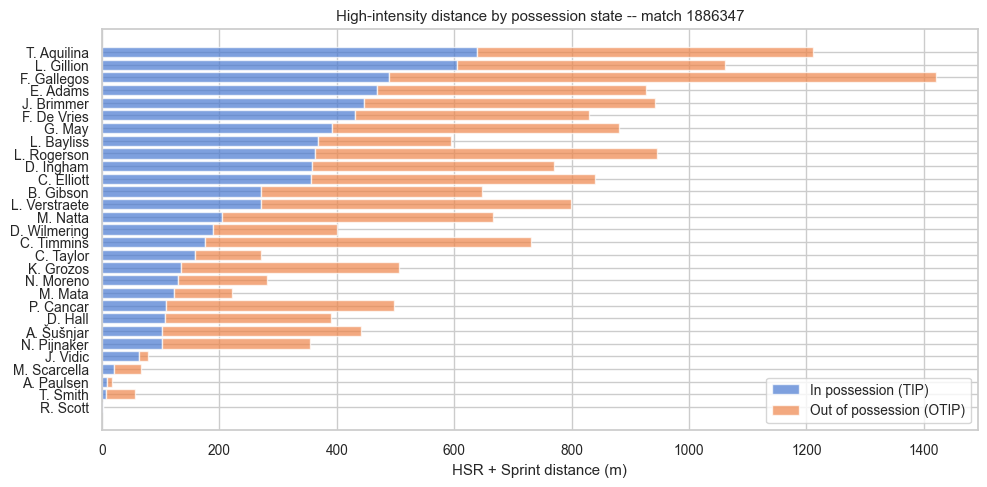

In [18]:
# HSR split by possession
hsr_poss = (
    tk[tk["speed"] >= SPEED_RUN]
    .groupby(["player_id", "in_possession"])["dist_frame"]
    .sum()
    .unstack(fill_value=0)
    .rename(columns={0.0: "hsr_otip", 1.0: "hsr_tip"})
    .reset_index()
)
for c in ["hsr_tip", "hsr_otip"]:
    if c not in hsr_poss.columns:
        hsr_poss[c] = 0.0
hsr_poss = hsr_poss.merge(
    players[["id", "short_name", "team"]],
    left_on="player_id", right_on="id", how="left",
)

fig, ax = plt.subplots(figsize=(10, 5))
d = hsr_poss.sort_values("hsr_tip", ascending=True)
ax.barh(d["short_name"], d["hsr_tip"],
        label="In possession (TIP)", alpha=0.7)
ax.barh(d["short_name"], d["hsr_otip"],
        left=d["hsr_tip"], label="Out of possession (OTIP)", alpha=0.7)
ax.set_xlabel("HSR + Sprint distance (m)")
ax.set_title(f"High-intensity distance by possession state -- match {MATCH_ID}")
ax.legend()
plt.tight_layout()
plt.show()

## 10 &ensp; Phase-of-Play Exposure

SkillCorner defines concurrent attacking/defending phase types.
Here we measure each player's **time exposure** (seconds) and **distance**
within each phase type.

In [19]:
# In-possession phase types
ip_exposure = (
    tk[tk["in_possession"] == 1]
    .groupby(["player_id", "phase_type_ip"])
    .agg(frames_ip=("frame", "count"), dist_ip=("dist_frame", "sum"))
    .reset_index()
)
ip_exposure["seconds_ip"] = ip_exposure["frames_ip"] / FPS
ip_exposure = ip_exposure.merge(
    players[["id", "short_name", "team", "player_role.acronym"]],
    left_on="player_id", right_on="id", how="left",
)

# Out-of-possession phase types
oop_exposure = (
    tk[tk["in_possession"] == 0]
    .groupby(["player_id", "phase_type_oop"])
    .agg(frames_oop=("frame", "count"), dist_oop=("dist_frame", "sum"))
    .reset_index()
)
oop_exposure["seconds_oop"] = oop_exposure["frames_oop"] / FPS
oop_exposure = oop_exposure.merge(
    players[["id", "short_name", "team", "player_role.acronym"]],
    left_on="player_id", right_on="id", how="left",
)

print("=== In-possession phase exposure (all players, seconds) ===")
print(ip_exposure.groupby("phase_type_ip")[["seconds_ip", "dist_ip"]]
      .sum().sort_values("seconds_ip", ascending=False)
      .to_string(float_format="%.0f"))

print("\n=== Out-of-possession phase exposure (all players, seconds) ===")
print(oop_exposure.groupby("phase_type_oop")[["seconds_oop", "dist_oop"]]
      .sum().sort_values("seconds_oop", ascending=False)
      .to_string(float_format="%.0f"))

=== In-possession phase exposure (all players, seconds) ===
               seconds_ip  dist_ip
phase_type_ip                     
create              14381    34832
finish               6939    15749
build_up             6255    13077
chaotic              3291     7046
set_play             2096     4398
direct                810     2329
transition            483     1483
quick_break           249      777

=== Out-of-possession phase exposure (all players, seconds) ===
                       seconds_oop  dist_oop
phase_type_oop                              
medium_block                 14381     37880
low_block                     6939     17164
high_block                    6255     14493
chaotic                       3291      7414
defending_set_play            2096      4351
defending_direct               810      2471
defending_transition           483      1706
defending_quick_break          249       842


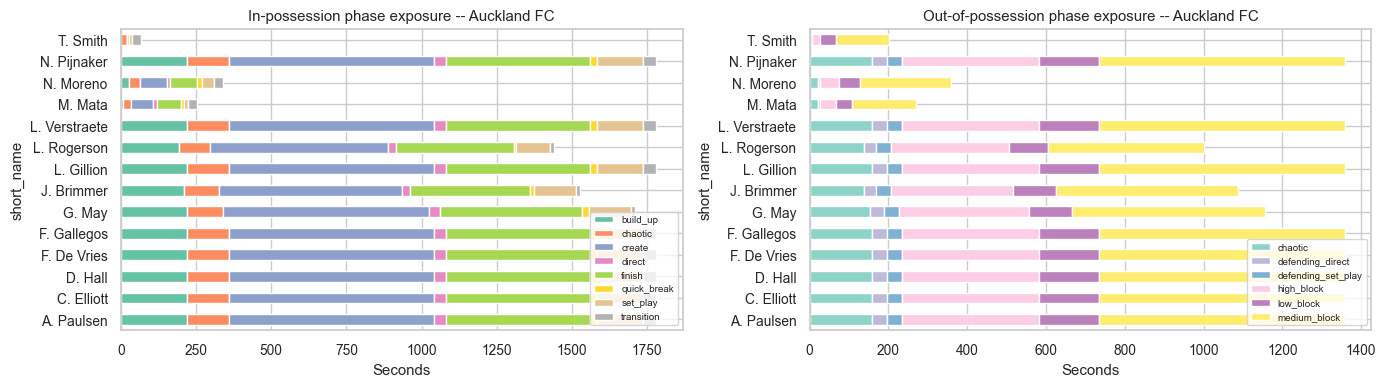

In [20]:
# Visualize phase-type exposure for one team
team_players = players[players["team"] == home_name]["id"].tolist()

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# In-possession phases
ip_team = ip_exposure[ip_exposure["player_id"].isin(team_players)]
ip_pivot = ip_team.pivot_table(index="short_name", columns="phase_type_ip",
                                values="seconds_ip", aggfunc="sum", fill_value=0)
ip_pivot.plot.barh(stacked=True, ax=axes[0], colormap="Set2")
axes[0].set_xlabel("Seconds")
axes[0].set_title(f"In-possession phase exposure -- {home_name}")
axes[0].legend(fontsize=7, loc="lower right")

# Out-of-possession phases
oop_team = oop_exposure[oop_exposure["player_id"].isin(team_players)]
oop_pivot = oop_team.pivot_table(index="short_name", columns="phase_type_oop",
                                  values="seconds_oop", aggfunc="sum", fill_value=0)
oop_pivot.plot.barh(stacked=True, ax=axes[1], colormap="Set3")
axes[1].set_xlabel("Seconds")
axes[1].set_title(f"Out-of-possession phase exposure -- {home_name}")
axes[1].legend(fontsize=7, loc="lower right")

plt.tight_layout()
plt.show()

## 11 &ensp; Season-Level Physical Aggregates

SkillCorner provides season-level aggregated physical data for Australian
A-League midfielders (performances > 60 min).  We compare these benchmarks
with our single-match computed values.

In [21]:
agg = pd.read_csv(AGG_CSV)
print(f"Aggregates: {agg.shape[0]} players x {agg.shape[1]} columns")
print(f"Columns: {list(agg.columns[:20])}")
agg[["player_name", "team_name", "position_group", "count_match",
     "total_distance_full_all", "total_metersperminute_full_all",
     "hsr_distance_full_all", "sprint_distance_full_all",
     "hi_distance_full_all", "medaccel_count_full_all",
     "highaccel_count_full_all"]].head(10)

Aggregates: 406 players x 65 columns
Columns: ['player_name', 'player_short_name', 'player_id', 'player_birthdate', 'team_name', 'team_id', 'competition_name', 'competition_id', 'season_name', 'season_id', 'position_group', 'minutes_full_all', 'minutes_full_tip', 'minutes_full_otip', 'count_match', 'count_match_failed', 'total_distance_full_all', 'total_metersperminute_full_all', 'running_distance_full_all', 'hsr_distance_full_all']


,player_name,team_name,position_group,count_match,total_distance_full_all,total_metersperminute_full_all,hsr_distance_full_all,sprint_distance_full_all,hi_distance_full_all,medaccel_count_full_all,highaccel_count_full_all
0,Adam Taggart,Perth Glory Football Club,Center Forward,24,10515.04,108.64,572.67,184.08,756.75,119.38,10.46
1,Adama Traoré,Melbourne Victory Football Club,Full Back,6,9173.67,103.02,430.67,141.33,572.00,102.17,5.33
2,Dino Arslanagić,Macarthur FC,Central Defender,8,9563.50,99.14,281.25,38.25,319.50,107.25,3.88
3,Douglas Costa de Souza,Sydney Football Club,Center Forward,4,10521.25,111.64,406.75,71.25,478.00,91.50,6.50
4,Douglas Costa de Souza,Sydney Football Club,Midfield,1,7843.00,116.08,318.00,10.00,328.00,67.00,3.00
5,Douglas Costa de Souza,Sydney Football Club,Wide Attacker,4,10349.25,109.07,551.75,95.75,647.50,97.00,7.00
6,Hiroki Sakai,Auckland FC,Central Defender,3,10025.00,101.19,412.67,177.33,590.00,108.33,5.33
7,Hiroki Sakai,Auckland FC,Full Back,21,9934.52,101.40,557.29,180.95,738.24,106.71,7.05
8,Javi López,Adelaide United Football Club,Full Back,6,9914.50,105.05,469.00,83.17,552.17,103.17,5.67
9,Joshua Brillante,Western Sydney Wanderers FC,Central Defender,4,8934.50,101.10,247.75,41.50,289.25,99.25,3.75


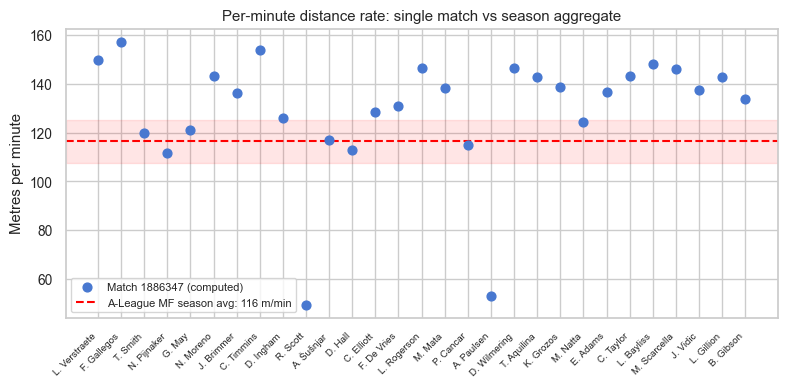

In [22]:
# Compare our computed per-minute rate with the aggregate benchmark
fig, ax = plt.subplots(figsize=(8, 4))

# our single-match data
our = player_dist[["short_name", "m_per_min", "player_role.acronym"]].dropna()
ax.scatter(our.index, our["m_per_min"],
           label=f"Match {MATCH_ID} (computed)", s=40, zorder=3)

# aggregate benchmark (mean +/- std)
agg_mean = agg["total_metersperminute_full_all"].mean()
agg_std  = agg["total_metersperminute_full_all"].std()
ax.axhline(agg_mean, color="red", ls="--",
           label=f"A-League MF season avg: {agg_mean:.0f} m/min")
ax.axhspan(agg_mean - agg_std, agg_mean + agg_std, alpha=0.1, color="red")

ax.set_ylabel("Metres per minute")
ax.set_title("Per-minute distance rate: single match vs season aggregate")
ax.set_xticks(our.index)
ax.set_xticklabels(our["short_name"], rotation=45, ha="right", fontsize=7)
ax.legend(fontsize=8)
plt.tight_layout()
plt.show()

## 12 &ensp; Multi-Match Pipeline: `player_match_physical` Table

Scale the single-match prototype to all 10 matches, producing one row per
player-match with the full set of physical features.

In [23]:
def process_match(match_id: int) -> pd.DataFrame:
    """Full pipeline for one match -> player-level physical summary."""
    # -- metadata --
    with open(MATCH_DIR / str(match_id) / f"{match_id}_match.json") as f:
        md_ = json.load(f)

    pl = pd.json_normalize(md_["players"], max_level=2)
    pl = pl[pl["start_time"].notna()].copy()
    pl["minutes_played"] = pl["playing_time.total.minutes_played"]
    h_id, a_id = md_["home_team"]["id"], md_["away_team"]["id"]
    h_name, a_name = md_["home_team"]["short_name"], md_["away_team"]["short_name"]
    pl["team"] = pl["team_id"].astype(int).map({h_id: h_name, a_id: a_name})
    player_team_map = pl.set_index("id")["team"].to_dict()

    # -- tracking --
    path = resolve_tracking_path(match_id)
    raw = pd.read_json(path, lines=True)
    t = pd.json_normalize(raw.to_dict("records"),
                          record_path="player_data",
                          meta=["frame", "timestamp", "period", "possession"])
    t["frame"]     = t["frame"].astype(int)
    t["player_id"] = t["player_id"].astype(int)
    t["is_detected"] = t["is_detected"].astype(bool)
    t = t.sort_values(["player_id", "frame"]).reset_index(drop=True)

    # -- kinematics (manual loop avoids groupby.apply pandas version issues) --
    t = pd.concat([compute_kinematics(g) for _, g in t.groupby("player_id")])
    t = t.reset_index(drop=True)

    # -- possession label --
    ph_path = MATCH_DIR / str(match_id) / f"{match_id}_phases_of_play.csv"
    ph = pd.read_csv(ph_path)
    t["player_team"] = t["player_id"].map(player_team_map)
    t["in_possession"] = np.nan
    for _, row in ph.iterrows():
        fm = (t["frame"] >= row["frame_start"]) & (t["frame"] <= row["frame_end"])
        tip_team = row["team_in_possession_shortname"]
        t.loc[fm & (t["player_team"] == tip_team), "in_possession"] = 1
        t.loc[fm & (t["player_team"] != tip_team) & t["player_team"].notna(),
              "in_possession"] = 0

    # -- aggregate --
    def player_summary(g):
        return pd.Series({
            "total_distance":     g["dist_frame"].sum(),
            "hsr_distance":       g.loc[g["speed"] >= SPEED_RUN, "dist_frame"].sum(),
            "sprint_distance":    g.loc[g["speed"] >= SPEED_SPRINT, "dist_frame"].sum(),
            "hsr_count":          count_bouts(g["speed"], SPEED_RUN),
            "sprint_count":       count_bouts(g["speed"], SPEED_SPRINT),
            "med_accel_count":    count_bouts(g["acceleration"], ACCEL_MED) - count_bouts(g["acceleration"], ACCEL_HIGH),
            "high_accel_count":   count_bouts(g["acceleration"], ACCEL_HIGH),
            "med_decel_count":    count_bouts(-g["acceleration"], ACCEL_MED) - count_bouts(-g["acceleration"], ACCEL_HIGH),
            "high_decel_count":   count_bouts(-g["acceleration"], ACCEL_HIGH),
            "max_speed":          g["speed"].max(),
            "mean_speed":         g["speed"].mean(),
            "dist_tip":           g.loc[g["in_possession"] == 1, "dist_frame"].sum(),
            "dist_otip":          g.loc[g["in_possession"] == 0, "dist_frame"].sum(),
            "hsr_dist_tip":       g.loc[(g["speed"] >= SPEED_RUN) & (g["in_possession"] == 1), "dist_frame"].sum(),
            "hsr_dist_otip":      g.loc[(g["speed"] >= SPEED_RUN) & (g["in_possession"] == 0), "dist_frame"].sum(),
            "n_frames":           len(g),
            "pct_detected":       g["is_detected"].mean() if "is_detected" in g.columns else np.nan,
        })

    summary = t.groupby("player_id").apply(player_summary).reset_index()
    summary["match_id"] = match_id
    summary["minutes"] = summary["n_frames"] / FPS / 60
    summary["m_per_min"] = summary["total_distance"] / summary["minutes"]

    # join player info
    summary = summary.merge(
        pl[["id", "short_name", "number", "player_role.acronym", "team", "minutes_played"]],
        left_on="player_id", right_on="id", how="left",
    )
    return summary

# Process first match -- verify pipeline
first_summary = process_match(MATCH_ID)
print(f"Match {MATCH_ID}: {len(first_summary)} player rows x {first_summary.shape[1]} cols")
first_summary[["short_name", "team", "total_distance", "hsr_distance",
               "sprint_distance", "m_per_min", "high_accel_count"]].head(10)

Match 1886347: 29 player rows x 27 cols


,short_name,team,total_distance,hsr_distance,sprint_distance,m_per_min,high_accel_count
0,L. Verstraete,Auckland FC,10844.423766,840.821538,48.939869,149.722819,25.0
1,F. Gallegos,Auckland FC,11384.195343,1497.972161,176.015777,157.175139,34.0
2,T. Smith,Auckland FC,832.942882,69.851633,25.542543,119.819163,3.0
3,N. Pijnaker,Auckland FC,8085.296029,380.969016,92.787598,111.629104,30.0
4,G. May,Auckland FC,7919.904715,915.944455,146.047911,120.954586,31.0
5,N. Moreno,Auckland FC,2430.424511,312.276826,100.718226,143.106448,9.0
6,J. Brimmer,Auckland FC,8128.669221,943.696783,195.037334,136.059854,29.0
7,C. Timmins,Newcastle,10061.819088,758.989182,113.777037,153.666390,21.0
8,D. Ingham,Newcastle,9138.294692,816.093312,201.807841,126.167261,49.0
9,R. Scott,Newcastle,3583.436099,1.746013,0.000000,49.474473,14.0


In [24]:
# Process all 10 matches (downloads tracking data if needed -- ~85 MB each)
all_match_ids = matches_meta["id"].tolist()
results = []
for mid in all_match_ids:
    print(f"\nProcessing match {mid} ...")
    try:
        res = process_match(mid)
        results.append(res)
        print(f"  ok: {len(res)} players")
    except Exception as e:
        print(f"  ERROR: {e}")

player_match_phys = pd.concat(results, ignore_index=True)
print(f"\n{'='*60}")
print(f"player_match_physical: {player_match_phys.shape[0]} rows x {player_match_phys.shape[1]} cols")
print(f"Matches: {player_match_phys['match_id'].nunique()}  |  "
      f"Players: {player_match_phys['player_id'].nunique()}")
player_match_phys.head()


Processing match 1886347 ...
  ok: 29 players

Processing match 1899585 ...
  ok: 30 players

Processing match 1925299 ...
  ok: 32 players

Processing match 1953632 ...
  ok: 30 players

Processing match 1996435 ...
  ok: 30 players

Processing match 2006229 ...
  ok: 32 players

Processing match 2011166 ...
  ok: 32 players

Processing match 2013725 ...
  ok: 30 players

Processing match 2015213 ...
  ok: 32 players

Processing match 2017461 ...
  ok: 32 players

player_match_physical: 309 rows x 27 cols
Matches: 10  |  Players: 206


,player_id,total_distance,hsr_distance,sprint_distance,hsr_count,sprint_count,med_accel_count,high_accel_count,med_decel_count,high_decel_count,max_speed,mean_speed,dist_tip,dist_otip,hsr_dist_tip,hsr_dist_otip,n_frames,pct_detected,match_id,minutes,m_per_min,id,short_name,number,player_role.acronym,team,minutes_played
0,14736,10844.423766,840.821538,48.939869,65.0,6.0,219.0,25.0,224.0,34.0,8.194402,2.479361,4850.008029,4229.083147,270.289630,528.625990,43458.0,0.722192,1886347,72.430000,149.722819,14736,L. Verstraete,6,DM,Auckland FC,98.40
1,23418,11384.195343,1497.972161,176.015777,103.0,17.0,233.0,34.0,274.0,40.0,8.786831,2.603713,5101.536227,4513.713543,488.803538,931.862118,43458.0,0.741659,1886347,72.430000,157.175139,23418,F. Gallegos,28,AM,Auckland FC,98.40
2,31147,832.942882,69.851633,25.542543,5.0,1.0,19.0,3.0,19.0,8.0,8.816045,1.969131,153.453033,488.750856,6.087138,49.453892,4171.0,0.476385,1886347,6.951667,119.819163,31147,T. Smith,5,CB,Auckland FC,11.75
3,33697,8085.296029,380.969016,92.787598,32.0,10.0,191.0,30.0,205.0,31.0,9.314762,1.844753,3537.141291,3080.377437,102.328683,252.580883,43458.0,0.440839,1886347,72.430000,111.629104,33697,N. Pijnaker,4,LCB,Auckland FC,98.40
4,38673,7919.904715,915.944455,146.047911,76.0,17.0,214.0,31.0,232.0,34.0,9.298316,2.001338,3588.062898,3061.136492,391.459212,489.262358,39287.0,0.586504,1886347,65.478333,120.954586,38673,G. May,10,CF,Auckland FC,86.65


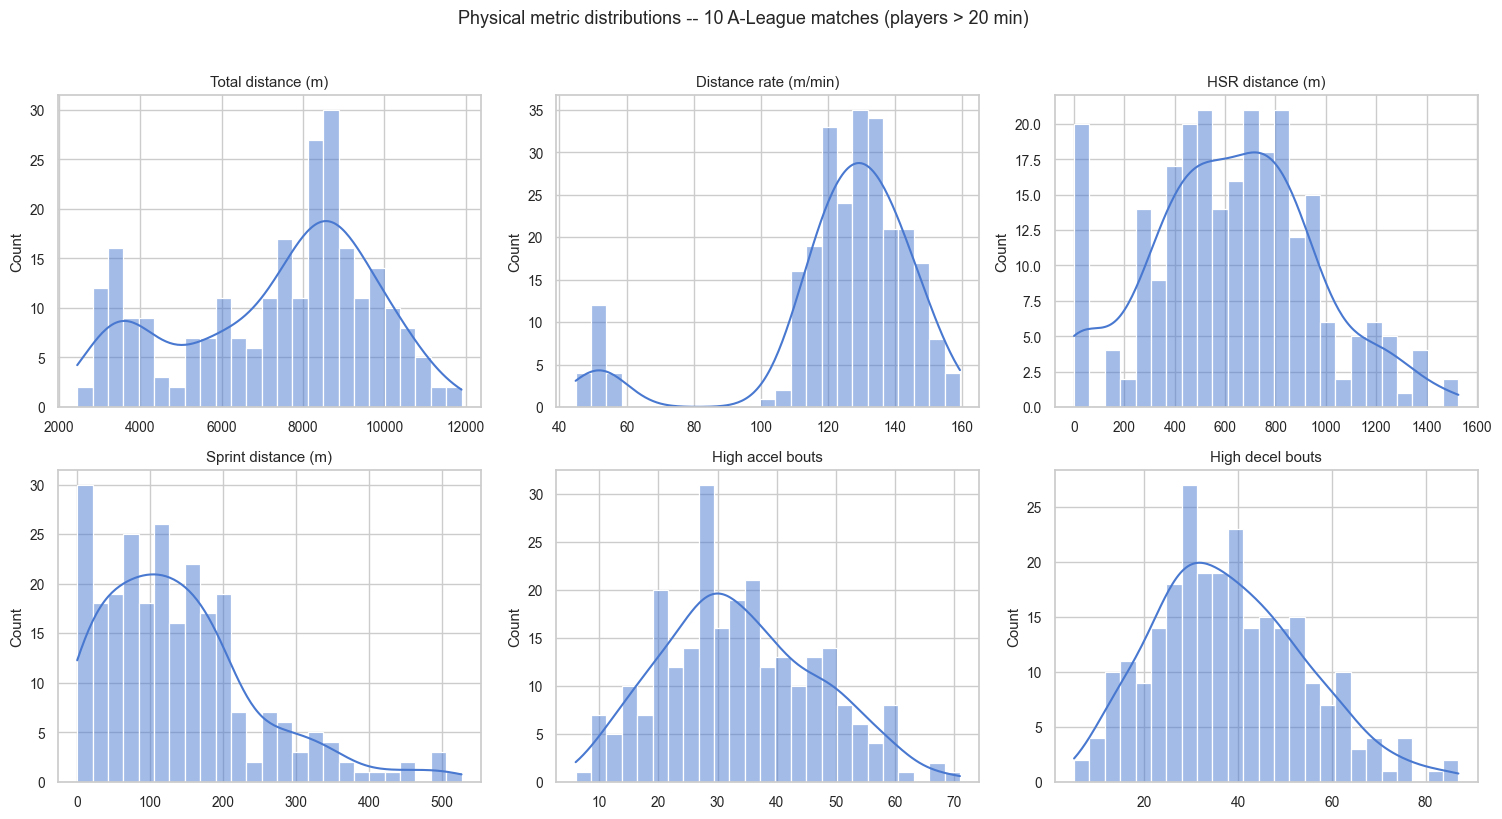

In [25]:
# Distribution of key metrics across all 10 matches
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
metrics = ["total_distance", "m_per_min", "hsr_distance",
           "sprint_distance", "high_accel_count", "high_decel_count"]
titles  = ["Total distance (m)", "Distance rate (m/min)", "HSR distance (m)",
           "Sprint distance (m)", "High accel bouts", "High decel bouts"]

for ax, metric, title in zip(axes.flat, metrics, titles):
    data = player_match_phys[player_match_phys["minutes"] > 20]
    sns.histplot(data[metric], ax=ax, kde=True, bins=25)
    ax.set_title(title)
    ax.set_xlabel("")

plt.suptitle("Physical metric distributions -- 10 A-League matches (players > 20 min)", y=1.02)
plt.tight_layout()
plt.show()

## 13 &ensp; Eight Standardized Questions

### Q1 -- What is the grain of the main table?
**Player x frame** for tracking (one row per player per 0.1 s frame).
The derived `player_match_physical` table has grain **player x match**.

### Q2 -- What are the main IDs and keys?
- `player_id` (SkillCorner internal, *not* Transfermarkt/StatsBomb)
- `match_id` (SkillCorner internal)
- `trackable_object` (numeric tracker ID)
- `team_id`

### Q3 -- What date fields exist?
- `date_time` in `matches.json` (UTC kick-off)
- `timestamp` per frame within match time
- No calendar-date column in tracking itself

### Q4 -- What can be used as labels, exposures, or features?
- **Labels:** None (no injury data in SkillCorner)
- **Exposures:** `minutes_played`, `minutes_tip`, `minutes_otip`
- **Features:** All physical metrics (distance, HSR, sprint, accel/decel counts,
  phase-of-play exposure, speed profiles)

### Q5 -- What are the major missingness / data quality issues?
- ~3% player-identity error (per SkillCorner documentation)
- Extrapolated positions when players are off-screen
- Speed/acceleration need smoothing (done above)
- Ball tracking may be incomplete in some frames

### Q6 -- What can be joined directly, and what requires fuzzy matching?
- **Cannot join directly** with Transfermarkt or StatsBomb (different player/match IDs)
- Player names allow **fuzzy matching** (short_name, first/last name)
- Team names are present but not standardised across sources
- **Different population** (A-League vs European leagues in other datasets)

### Q7 -- What 10 candidate features could this dataset contribute?

| # | Feature | Description |
|---|---------|-------------|
| 1 | `total_distance` | Sum of frame-to-frame displacements |
| 2 | `m_per_min` | Distance rate (workload intensity proxy) |
| 3 | `hsr_distance` | Distance covered >= 5.5 m/s |
| 4 | `sprint_distance` | Distance covered >= 7.0 m/s |
| 5 | `hsr_count` | Number of HSR bouts |
| 6 | `sprint_count` | Number of sprint bouts |
| 7 | `high_accel_count` | Explosive acceleration bouts (>= 4 m/s^2) |
| 8 | `high_decel_count` | Hard braking bouts (<= -4 m/s^2) |
| 9 | `dist_tip` / `dist_otip` | Distance split by possession state |
| 10 | `hsr_dist_otip` | HSR distance out of possession (pressing proxy) |

### Q8 -- Should this source be considered core, auxiliary, or prototype-only?

**Prototype-only.**

The SkillCorner open data covers 10 A-League matches with SkillCorner-specific
player IDs.  It cannot be joined to the Transfermarkt/StatsBomb injury and
exposure backbone without fuzzy name matching, and the population (Australian
league) is different from the target (UEFA men's leagues).

However, the **methods prototyped here** -- speed smoothing, distance computation,
HSR/sprint thresholds, acceleration counting, possession-phase splits -- are
directly transferable to any future tracking data source.

## 14 &ensp; `player_match_physical` -- Final Schema

The output table is ready for downstream use (or export to CSV):

| Column | Type | Description |
|--------|------|-------------|
| `match_id` | int | SkillCorner match identifier |
| `player_id` | int | SkillCorner player identifier |
| `short_name` | str | Player display name |
| `team` | str | Team short name |
| `player_role.acronym` | str | Position code (CF, LB, CDM, ...) |
| `minutes` | float | Minutes tracked |
| `total_distance` | float | Total distance (m) |
| `m_per_min` | float | Distance rate (m/min) |
| `hsr_distance` | float | HSR distance >= 5.5 m/s (m) |
| `sprint_distance` | float | Sprint distance >= 7.0 m/s (m) |
| `hsr_count` | int | Number of HSR bouts |
| `sprint_count` | int | Number of sprint bouts |
| `med_accel_count` | int | Medium acceleration bouts |
| `high_accel_count` | int | High acceleration bouts |
| `med_decel_count` | int | Medium deceleration bouts |
| `high_decel_count` | int | High deceleration bouts |
| `max_speed` | float | Peak smoothed speed (m/s) |
| `dist_tip` | float | Distance in possession (m) |
| `dist_otip` | float | Distance out of possession (m) |
| `hsr_dist_tip` | float | HSR distance in possession (m) |
| `hsr_dist_otip` | float | HSR distance out of possession (m) |
| `pct_detected` | float | Fraction of frames with positive detection |

In [26]:
# Save to CSV for cross-notebook use
out_path = ROOT / "data" / "processed"
out_path.mkdir(parents=True, exist_ok=True)
player_match_phys.to_csv(out_path / "player_match_physical_skillcorner.csv", index=False)
print(f"Saved: {out_path / 'player_match_physical_skillcorner.csv'}")
print(f"Shape: {player_match_phys.shape}")

Saved: c:\Users\storm\Documents\Courses_IMT_Atlantique\A Journey to a Data Scientist\Business Problem\data_exploration\data\processed\player_match_physical_skillcorner.csv
Shape: (309, 27)
